In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [3]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [4]:
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

In [5]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

In [6]:
input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

In [7]:
autoencoder.compile(optimizer='adam',
                    loss='binary_crossentropy')

In [8]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - loss: 0.1758 - val_loss: 0.1226
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - loss: 0.1184 - val_loss: 0.1133
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - loss: 0.1123 - val_loss: 0.1091
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - loss: 0.1089 - val_loss: 0.1065
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 0.1065 - val_loss: 0.1048
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - loss: 0.1048 - val_loss: 0.1030
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - loss: 0.1035 - val_loss: 0.1022
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 0.1025 - val_loss: 0.1012
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - loss: 0.1017 - val_loss: 0.1007
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - loss: 0.1011 - val_loss: 0.1000


In [9]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


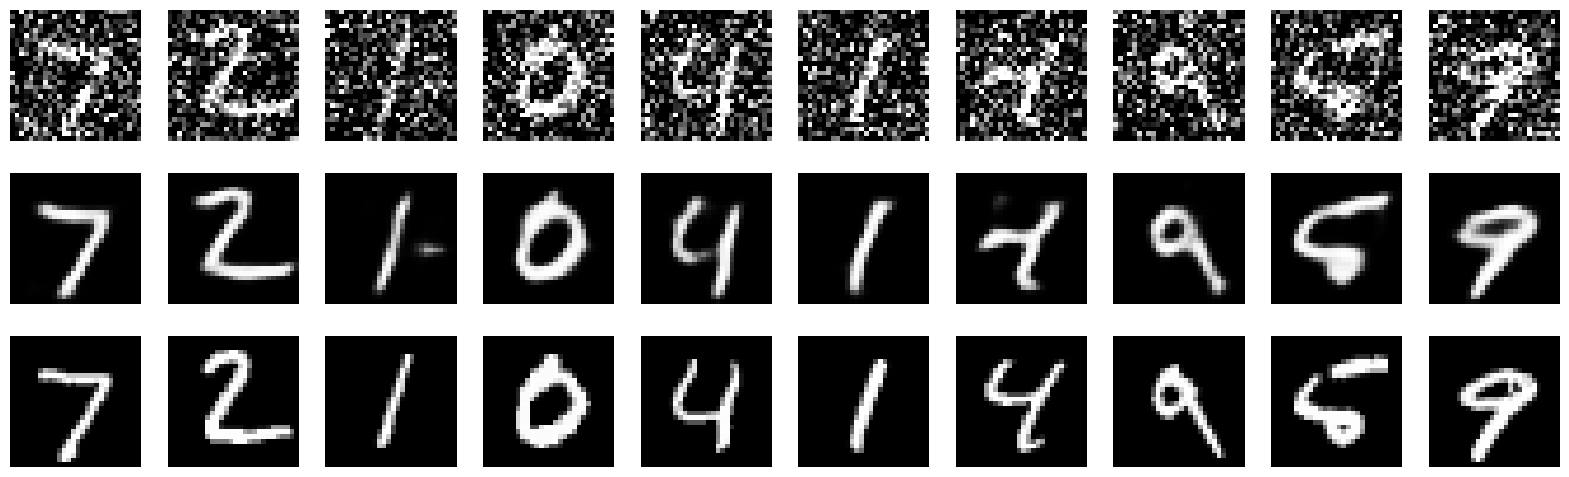

In [10]:
n = 10

plt.figure(figsize=(20,6))

for i in range(n):

    # Noisy
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(3, n, i+n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # Original
    ax = plt.subplot(3, n, i+2*n+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()